# 2026-06-08 FA 요인분석 - 매칭비발생

같은 기상셀·월·시간대의 매칭 비발생 대조군을 만들고, 산불 시점이 평상시보다 얼마나 위험 방향으로 이탈했는지를 FA 입력으로 준비한다.


# 데이터 준비

`jsw/강원_EDA/README.md`의 결합 방식을 따르되, 날씨 변수는 매칭 비발생 평균 대비 `위험방향_delta`로 변환한다.


## 0. 환경 설정

In [1]:
from pathlib import Path
import gc
import math
import time
import warnings

import geopandas as gpd
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from shapely import wkt
from shapely.strtree import STRtree

warnings.filterwarnings("ignore")

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print

    def Markdown(text):
        return text


font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False
    }
)

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("현재 matplotlib font.sans-serif:", plt.rcParams["font.sans-serif"][:3])

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents, Path("D:/farm-system-public-02")]:
    if (candidate / "data").exists() and (candidate / "jsw").exists():
        ROOT = candidate
        break

WEATHER_DIR = ROOT / "data" / "강원도_날씨데이터"
FIRE_DIR = ROOT / "data" / "강원도_데이터"
SPATIAL_DIR = FIRE_DIR / "강원도_공간데이터"
FIRE_SPATIAL_DIR = FIRE_DIR / "산불_공간데이터"

TYPE_ORDER = ["영동 해안형", "영서 내륙형", "고지·산간형"]
ADDR_ORDER = ["임야번지(산)", "일반번지"]
CAUSE_ORDER = ["입산활동 발화 후보", "기타 인간활동 발화 후보"]
RANDOM_STATE = 20260608

print("ROOT:", ROOT)
print("matplotlib font:", plt.rcParams["font.family"])


현재 matplotlib font.family: ['Malgun Gothic']
현재 matplotlib font.sans-serif: ['Malgun Gothic']
ROOT: d:\farm-system-public-02
matplotlib font: ['Malgun Gothic']


## 1. 공통 함수

In [2]:
def read_gpkg(path, columns=None):
    """pyogrio가 가능하면 사용하고, 아니면 geopandas 기본 엔진으로 읽는다."""
    try:
        return gpd.read_file(path, engine="pyogrio", columns=columns)
    except Exception:
        return gpd.read_file(path, columns=columns)


def valid_summary(df, columns):
    rows = []
    for col in columns:
        exists = col in df.columns
        rows.append({
            "변수": col,
            "전체행": len(df),
            "유효표본수": int(df[col].notna().sum()) if exists else 0,
            "결측수": int(df[col].isna().sum()) if exists else len(df),
            "결측률_pct": round(float(df[col].isna().mean() * 100), 2) if exists else 100.0,
        })
    return pd.DataFrame(rows)


def build_spatial_index(geoms):
    geom_arr = np.asarray(pd.Series(geoms).dropna().values, dtype=object)
    return geom_arr, STRtree(geom_arr)


def nearest_distance_from_index(points_gdf, geom_arr, tree, label):
    if len(geom_arr) == 0:
        return [np.nan] * len(points_gdf)
    out = []
    for pt in np.asarray(points_gdf.geometry.values, dtype=object):
        nearest = tree.nearest(pt)
        geom = geom_arr[int(nearest)] if isinstance(nearest, (int, np.integer)) else nearest
        out.append(pt.distance(geom))
    print(f"- {label} 최단거리 완료")
    return out


def add_rolling_weather(hourly):
    """현재 발생시각은 제외하고 직전 24/48/72시간 rolling 기상값을 만든다."""
    hourly = hourly.sort_values(["기상셀ID", "일시"]).reset_index(drop=True)
    shifted = hourly.groupby("기상셀ID", sort=False)[["풍속_m_s", "습도_pct", "강수량_mm"]].shift(1)
    grouped = shifted.groupby(hourly["기상셀ID"], sort=False)
    for window in [24, 48, 72]:
        hourly[f"직전{window}h_평균풍속"] = (
            grouped["풍속_m_s"].rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_최소습도"] = (
            grouped["습도_pct"].rolling(window, min_periods=1).min().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_강수량합"] = (
            grouped["강수량_mm"].rolling(window, min_periods=1).sum().reset_index(level=0, drop=True)
        )
    return hourly


## 2. 산불 기본정보, 기상셀, 기후지형유형, 지형 결합

In [3]:
t0 = time.time()

fire = pd.read_csv(FIRE_DIR / "강원도_산불발생.csv", encoding="utf-8-sig")
grid = gpd.read_file(WEATHER_DIR / "강원도날씨_격자.geojson").to_crs("EPSG:4326")
climate_type = pd.read_csv(WEATHER_DIR / "강원도날씨_기후지형유형_셀분류.csv", encoding="utf-8-sig")
topo = pd.read_csv(FIRE_SPATIAL_DIR / "강원도_산불_지형특성계산.csv", encoding="utf-8-sig")

fire["발생일시"] = pd.to_datetime(
    dict(year=fire["연도"], month=fire["월"], day=fire["일"]),
    errors="coerce",
) + pd.to_timedelta(fire["시간"].fillna(0).astype(int), unit="h")
fire["날짜"] = fire["발생일시"].dt.floor("D")
fire["월_key"] = fire["발생일시"].dt.month
fire["시간_key"] = fire["발생일시"].dt.hour
fire["산불위험계절"] = np.where(
    fire["월_key"].isin([11, 12, 1, 2, 3, 4, 5]),
    "산불위험계절(11~5월)",
    "기타계절",
)
fire["addr_type"] = np.where(
    fire["발생지역번지"].fillna("").astype(str).str.strip().str.startswith("산"),
    "임야번지(산)",
    "일반번지",
)
fire["발생시간대구분"] = pd.cut(
    fire["시간_key"],
    bins=[-0.1, 5, 9, 13, 17, 23],
    labels=["야간(0~5시)", "아침(6~9시)", "한낮(10~13시)", "오후(14~17시)", "저녁(18~23시)"],
)

fire_gdf = gpd.GeoDataFrame(
    fire,
    geometry=gpd.points_from_xy(fire["경도"], fire["위도"]),
    crs="EPSG:4326",
)
fire_cells = gpd.sjoin(
    fire_gdf,
    grid[["기상셀ID", "기후권역", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"])

unmatched_ids = fire_cells.loc[fire_cells["기상셀ID"].isna(), "fire_id"].tolist()
fire_cells = fire_cells[fire_cells["기상셀ID"].notna()].drop(columns=["geometry"]).copy()
fire_cells = fire_cells.merge(climate_type[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left")

fire_core = fire_cells.merge(topo.drop(columns=["위도", "경도"]), on="fire_id", how="left")
fire_core.loc[fire_core["TWI(지형다습지수)"] > 1e8, "TWI(지형다습지수)"] = np.nan
fire_core["사면방향_deg"] = (
    np.degrees(np.arctan2(fire_core["사면방향_sin"], fire_core["사면방향_cos"])) + 360
) % 360

for col in ["기후지형유형", "addr_type"]:
    if col == "기후지형유형":
        fire_core[col] = pd.Categorical(fire_core[col], categories=TYPE_ORDER, ordered=True)
    else:
        fire_core[col] = pd.Categorical(fire_core[col], categories=ADDR_ORDER, ordered=True)

print(f"산불 원자료: {len(fire):,}건")
print(f"기상셀 매칭 후: {len(fire_core):,}건")
print(f"미매칭 제외 fire_id: {unmatched_ids}")

del topo, fire_gdf, fire_cells
gc.collect()


산불 원자료: 3,405건
기상셀 매칭 후: 3,401건
미매칭 제외 fire_id: ['F_006690', 'F_009678', 'F_010665', 'F_010893']


20

## 3. 토지피복과 접근성 최단거리 결합

In [4]:
land = read_gpkg(
    SPATIAL_DIR / "강원도_토지피복도_세분류_병합_1m.gpkg",
    columns=["L1_NAME", "L2_NAME"],
)
land["L1_NAME"] = land["L1_NAME"].fillna("미분류")
land["L2_NAME"] = land["L2_NAME"].fillna("미분류")

fire_points = gpd.GeoDataFrame(
    fire_core,
    geometry=gpd.points_from_xy(fire_core["경도"], fire_core["위도"]),
    crs="EPSG:4326",
).to_crs(land.crs)

fire_lc = gpd.sjoin(
    fire_points,
    land[["L1_NAME", "L2_NAME", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"])
fire_lc = fire_lc.drop_duplicates(subset="fire_id").reset_index(drop=True)
fire_lc["L1_NAME"] = fire_lc["L1_NAME"].fillna("미분류")
fire_lc["L2_NAME"] = fire_lc["L2_NAME"].fillna("미분류")

road = read_gpkg(SPATIAL_DIR / "강원도_병합_도로.gpkg", columns=[]).to_crs(land.crs)
trail_df = pd.read_csv(SPATIAL_DIR / "강원도_등산로.csv", encoding="utf-8-sig")
trail = gpd.GeoDataFrame(trail_df, geometry=trail_df["공간좌표"].apply(wkt.loads), crs="EPSG:4326").to_crs(land.crs)
imdo_df = pd.read_csv(SPATIAL_DIR / "강원도_임도망도.csv", encoding="utf-8-sig")
imdo = gpd.GeoDataFrame(imdo_df, geometry=imdo_df["공간좌표"].apply(wkt.loads), crs="EPSG:4326").to_crs(land.crs)

target_indices = {
    "도로": build_spatial_index(road.geometry),
    "임도": build_spatial_index(imdo.geometry),
    "등산로": build_spatial_index(trail.geometry),
    "산림지역": build_spatial_index(land.loc[land["L1_NAME"].eq("산림지역"), "geometry"]),
    "시가화건조지역": build_spatial_index(land.loc[land["L1_NAME"].eq("시가화건조지역"), "geometry"]),
    "농업지역": build_spatial_index(land.loc[land["L1_NAME"].eq("농업지역"), "geometry"]),
}

distance_specs = [
    ("도로", "도로_최단거리_m"),
    ("임도", "임도_최단거리_m"),
    ("등산로", "등산로_최단거리_m"),
    ("산림지역", "산림_최단거리_m"),
    ("시가화건조지역", "시가화_최단거리_m"),
    ("농업지역", "농업_최단거리_m"),
]
for label, col in distance_specs:
    geom_arr, tree = target_indices[label]
    fire_lc[col] = nearest_distance_from_index(fire_lc, geom_arr, tree, label)
    fire_lc[f"log1p_{col}"] = np.log1p(fire_lc[col])

fire_lc["생활권프록시"] = np.where(
    (fire_lc["도로_최단거리_m"] <= 30)
    | (fire_lc["시가화_최단거리_m"] <= 100)
    | (fire_lc["농업_최단거리_m"] <= 100),
    "도로/시가화/농업 인접",
    "비인접",
)
fire_lc["원인프록시_500m"] = np.where(
    (fire_lc["등산로_최단거리_m"] <= 500) | (fire_lc["임도_최단거리_m"] <= 500),
    "입산활동 발화 후보",
    "기타 인간활동 발화 후보",
)
fire_lc["원인프록시_500m"] = pd.Categorical(fire_lc["원인프록시_500m"], categories=CAUSE_ORDER, ordered=True)
fire_lc["기후지형_번지유형"] = (
    fire_lc["기후지형유형"].astype(str) + " / " + fire_lc["addr_type"].astype(str)
)

del fire_core, fire_points, road
gc.collect()

print("토지피복/접근성 결합 완료")


- 도로 최단거리 완료
- 임도 최단거리 완료
- 등산로 최단거리 완료
- 산림지역 최단거리 완료
- 시가화건조지역 최단거리 완료
- 농업지역 최단거리 완료
토지피복/접근성 결합 완료


## 4. 발생시각·선행 날씨 결합

In [5]:
daily = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_일단위.csv", encoding="utf-8-sig")
hourly = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_시간단위.csv", encoding="utf-8-sig")

daily["날짜"] = pd.to_datetime(daily["날짜"])
hourly["일시"] = pd.to_datetime(hourly["일시"])
hourly["날짜"] = hourly["일시"].dt.floor("D")
hourly["월_key"] = hourly["일시"].dt.month.astype("int8")
hourly["시간_key"] = hourly["일시"].dt.hour.astype("int8")
hourly = add_rolling_weather(hourly)

hourly_day = (
    hourly.groupby(["기상셀ID", "날짜"], as_index=False)
    .agg(
        최소습도_pct=("습도_pct", "min"),
        강수량합_mm=("강수량_mm", "sum"),
    )
)

hourly_features = hourly[
    [
        "기상셀ID", "일시", "날짜", "월_key", "시간_key",
        "풍속_m_s", "강수량_mm", "습도_pct",
        "직전24h_평균풍속", "직전24h_최소습도", "직전24h_강수량합",
        "직전48h_평균풍속", "직전48h_최소습도", "직전48h_강수량합",
        "직전72h_평균풍속", "직전72h_최소습도", "직전72h_강수량합",
    ]
].copy()
hourly_features = hourly_features.rename(
    columns={
        "풍속_m_s": "시점_풍속_m_s",
        "강수량_mm": "시점_강수량_mm",
        "습도_pct": "시점_습도_pct",
    }
)

daily_features = daily.rename(columns={"최대순간풍속_m_s": "당일_최대순간풍속_m_s"})
hourly_features = hourly_features.merge(
    daily_features[["기상셀ID", "날짜", "당일_최대순간풍속_m_s"]],
    on=["기상셀ID", "날짜"],
    how="left",
)

for lag in [1, 2, 3]:
    lag_df = hourly_day.copy()
    lag_df["날짜"] = lag_df["날짜"] + pd.Timedelta(days=lag)
    lag_df = lag_df.rename(
        columns={
            "최소습도_pct": f"D-{lag}_최소습도_pct",
            "강수량합_mm": f"D-{lag}_강수량합_mm",
        }
    )
    hourly_features = hourly_features.merge(lag_df, on=["기상셀ID", "날짜"], how="left")

float_cols = hourly_features.select_dtypes(include=["float64"]).columns
hourly_features[float_cols] = hourly_features[float_cols].astype("float32")

fire_lc = fire_lc.merge(
    hourly_features.rename(columns={"일시": "발생일시"}),
    on=["기상셀ID", "발생일시"],
    how="left",
    suffixes=("", "_weather"),
)

del daily, hourly, hourly_day, daily_features
gc.collect()

print(f"날씨 결합 완료: {time.time() - t0:.1f}초")
display(
    valid_summary(
        fire_lc,
        [
            "시점_습도_pct", "시점_풍속_m_s", "시점_강수량_mm",
            "직전24h_최소습도", "직전48h_최소습도", "직전72h_최소습도",
            "직전24h_평균풍속", "직전48h_평균풍속", "직전72h_평균풍속",
            "D-1_최소습도_pct", "D-2_최소습도_pct", "D-3_최소습도_pct",
            "고도(m)", "경사도(도)", "TPI(지형위치지수)", "TWI(지형다습지수)",
            "도로_최단거리_m", "임도_최단거리_m", "등산로_최단거리_m",
        ],
    )
)


날씨 결합 완료: 36.5초


,변수,전체행,유효표본수,결측수,결측률_pct
0,시점_습도_pct,3401,3401,0,0.00
1,시점_풍속_m_s,3401,3401,0,0.00
2,시점_강수량_mm,3401,3401,0,0.00
3,직전24h_최소습도,3401,3401,0,0.00
4,직전48h_최소습도,3401,3401,0,0.00
5,직전72h_최소습도,3401,3401,0,0.00
6,직전24h_평균풍속,3401,3401,0,0.00
7,직전48h_평균풍속,3401,3401,0,0.00
8,직전72h_평균풍속,3401,3401,0,0.00
9,D-1_최소습도_pct,3401,3399,2,0.06


## 5. 매칭 비발생 대조군 생성 및 품질 진단

같은 `기상셀ID`, 같은 `월_key`, 같은 `시간_key`의 비발생 시점을 산불 1건당 최대 5개 추출한다.
산불 발생시각 자체와 발생시각 전후 72시간은 대조군 후보에서 제외한다.


In [6]:
MATCH_N_PER_FIRE = 5
CONTROL_EXCLUDE_WINDOW_HOURS = 72
MATCH_GROUP_COLS = ["기상셀ID", "월_key", "시간_key"]


def make_matched_controls(
    fire_df,
    hourly_feature_df,
    n_per_fire=5,
    exclude_window_hours=72,
    random_state=RANDOM_STATE,
):
    required_fire_cols = ["fire_id", "기상셀ID", "발생일시", "월_key", "시간_key"]
    required_hourly_cols = ["기상셀ID", "일시", "월_key", "시간_key"]
    missing_fire = [col for col in required_fire_cols if col not in fire_df.columns]
    missing_hourly = [col for col in required_hourly_cols if col not in hourly_feature_df.columns]
    if missing_fire:
        raise KeyError(f"fire_df 누락 컬럼: {missing_fire}")
    if missing_hourly:
        raise KeyError(f"hourly_feature_df 누락 컬럼: {missing_hourly}")

    fire_key_frame = fire_df[["기상셀ID", "발생일시"]].rename(columns={"발생일시": "일시"})
    fire_keys = pd.MultiIndex.from_frame(fire_key_frame)

    candidates = hourly_feature_df.copy().reset_index(drop=True)
    candidates["일시"] = pd.to_datetime(candidates["일시"])
    hourly_keys = pd.MultiIndex.from_frame(candidates[["기상셀ID", "일시"]])
    candidates = candidates.loc[~hourly_keys.isin(fire_keys)].reset_index(drop=True)

    group_indices = candidates.groupby(MATCH_GROUP_COLS, sort=False).indices
    rng = np.random.default_rng(random_state)
    exclude_delta = pd.Timedelta(hours=exclude_window_hours)

    parts = []
    match_rows = []

    for _, row in fire_df.iterrows():
        key = tuple(row[col] for col in MATCH_GROUP_COLS)
        idxs = group_indices.get(key)
        raw_candidate_count = 0 if idxs is None else len(idxs)
        selected_count = 0

        if idxs is not None and raw_candidate_count > 0:
            candidate_part = candidates.iloc[idxs].copy()
            if exclude_window_hours is not None and exclude_window_hours > 0:
                time_diff = (candidate_part["일시"] - row["발생일시"]).abs()
                candidate_part = candidate_part.loc[time_diff > exclude_delta].copy()

            available_after_window = len(candidate_part)
            if available_after_window > 0:
                take_size = min(n_per_fire, available_after_window)
                take_pos = rng.choice(candidate_part.index.to_numpy(), size=take_size, replace=False)
                part = candidates.loc[take_pos].copy()
                part["fire_id"] = row["fire_id"]
                part["source_fire_time"] = row["발생일시"]
                part["source_weather_cell_id"] = row["기상셀ID"]
                part["control_rank"] = np.arange(1, len(part) + 1)
                part["control_time_diff_hours"] = (
                    (part["일시"] - row["발생일시"]).abs() / pd.Timedelta(hours=1)
                ).astype("float32")
                parts.append(part)
                selected_count = len(part)
        else:
            available_after_window = 0

        match_rows.append(
            {
                "fire_id": row["fire_id"],
                "기상셀ID": row["기상셀ID"],
                "발생일시": row["발생일시"],
                "월_key": row["월_key"],
                "시간_key": row["시간_key"],
                "raw_candidate_count": raw_candidate_count,
                "available_after_window_count": available_after_window,
                "selected_control_count": selected_count,
            }
        )

    matched = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    match_status = pd.DataFrame(match_rows)
    return matched, match_status


matched_controls, match_status = make_matched_controls(
    fire_lc,
    hourly_features,
    n_per_fire=MATCH_N_PER_FIRE,
    exclude_window_hours=CONTROL_EXCLUDE_WINDOW_HOURS,
    random_state=RANDOM_STATE,
)

if len(matched_controls) > 0:
    matched_keys = pd.MultiIndex.from_frame(matched_controls[["기상셀ID", "일시"]])
    matched_controls["일시"] = pd.to_datetime(matched_controls["일시"])
else:
    matched_keys = pd.MultiIndex.from_arrays([[], []], names=["기상셀ID", "일시"])

fire_keys_check = pd.MultiIndex.from_frame(
    fire_lc[["기상셀ID", "발생일시"]].rename(columns={"발생일시": "일시"})
)
matched_overlap = bool(matched_keys.isin(fire_keys_check).any()) if len(matched_controls) else False

match_status = match_status.merge(
    fire_lc[
        [
            "fire_id", "기후권역", "기후지형유형", "addr_type",
            "기후지형_번지유형", "산불위험계절", "L1_NAME", "L2_NAME",
        ]
    ],
    on="fire_id",
    how="left",
)
match_status["match_status"] = np.select(
    [
        match_status["selected_control_count"].eq(0),
        match_status["selected_control_count"].lt(MATCH_N_PER_FIRE),
    ],
    ["매칭없음", "목표미만"],
    default="목표충족",
)

matching_quality_summary = pd.DataFrame(
    {
        "항목": [
            "기상셀 매칭 산불",
            "매칭 비발생 행 수",
            "목표 매칭 수",
            "전후 제외 시간",
            "매칭 산불 수",
            "매칭 없음 산불 수",
            "목표 미만 산불 수",
            "산불 1건당 평균 선택 매칭 수",
            "산불 발생시점과 대조군 중복 여부",
        ],
        "값": [
            len(fire_lc),
            len(matched_controls),
            MATCH_N_PER_FIRE,
            f"±{CONTROL_EXCLUDE_WINDOW_HOURS}h",
            int(match_status["selected_control_count"].gt(0).sum()),
            int(match_status["selected_control_count"].eq(0).sum()),
            int(match_status["selected_control_count"].between(1, MATCH_N_PER_FIRE - 1).sum()),
            round(float(match_status["selected_control_count"].mean()), 3),
            matched_overlap,
        ],
    }
)

match_count_distribution = (
    match_status["selected_control_count"]
    .value_counts()
    .sort_index()
    .rename_axis("selected_control_count")
    .reset_index(name="fire_count")
)

match_quality_by_climate_addr = (
    match_status
    .groupby("기후지형_번지유형", observed=False)
    .agg(
        산불수=("fire_id", "count"),
        평균선택매칭수=("selected_control_count", "mean"),
        매칭없음수=("selected_control_count", lambda s: int((s == 0).sum())),
        목표미만수=("selected_control_count", lambda s: int(((s > 0) & (s < MATCH_N_PER_FIRE)).sum())),
    )
    .reset_index()
)

display(Markdown("### 매칭 비발생 대조군 품질 요약"))
display(matching_quality_summary)
display(Markdown("### 산불 1건당 선택 매칭 수 분포"))
display(match_count_distribution)
display(Markdown("### 기후지형_번지유형별 매칭 품질"))
display(match_quality_by_climate_addr)

print("생성 객체:")
print("- matched_controls: 같은 기상셀·월·시간대 매칭 비발생 시점")
print("- match_status: 산불 1건별 매칭 가능/선택 수")
print("- matching_quality_summary: 매칭 품질 요약")


### 매칭 비발생 대조군 품질 요약

,항목,값
0,기상셀 매칭 산불,3401
1,매칭 비발생 행 수,17005
2,목표 매칭 수,5
3,전후 제외 시간,±72h
4,매칭 산불 수,3401
5,매칭 없음 산불 수,0
6,목표 미만 산불 수,0
7,산불 1건당 평균 선택 매칭 수,5.0
8,산불 발생시점과 대조군 중복 여부,False


### 산불 1건당 선택 매칭 수 분포

,selected_control_count,fire_count
0,5,3401


### 기후지형_번지유형별 매칭 품질

,기후지형_번지유형,산불수,평균선택매칭수,매칭없음수,목표미만수
0,고지·산간형 / 일반번지,413,5.0,0,0
1,고지·산간형 / 임야번지(산),209,5.0,0,0
2,영동 해안형 / 일반번지,975,5.0,0,0
3,영동 해안형 / 임야번지(산),246,5.0,0,0
4,영서 내륙형 / 일반번지,1228,5.0,0,0
5,영서 내륙형 / 임야번지(산),330,5.0,0,0


생성 객체:
- matched_controls: 같은 기상셀·월·시간대 매칭 비발생 시점
- match_status: 산불 1건별 매칭 가능/선택 수
- matching_quality_summary: 매칭 품질 요약


## 6. 위험방향 delta 및 FA 입력 데이터셋 구성

기상 변수는 매칭 비발생 평균 대비 위험방향 delta로 변환한다.
습도·강수는 낮을수록 위험하므로 `대조군 평균 - 산불값`, 풍속은 높을수록 위험하므로 `산불값 - 대조군 평균`으로 계산한다.


In [7]:
META_COLS = [
    "fire_id", "발생일시", "기상셀ID", "기후권역", "기후지형유형",
    "addr_type", "기후지형_번지유형", "월_key", "시간_key", "산불위험계절",
    "발생시간대구분", "L1_NAME", "L2_NAME",
    "생활권프록시", "원인프록시_500m",
]

TOPO_FEATURE_COLS = [
    "고도(m)", "경사도(도)", "사면방향_sin", "사면방향_cos",
    "TPI(지형위치지수)", "TWI(지형다습지수)",
]

ACCESS_FEATURE_COLS = [
    "log1p_도로_최단거리_m", "log1p_임도_최단거리_m", "log1p_등산로_최단거리_m",
    "log1p_산림_최단거리_m", "log1p_시가화_최단거리_m", "log1p_농업_최단거리_m",
]

MATCHED_WEATHER_SPECS = [
    ("시점_습도_pct", "발생시각_습도_위험방향_delta", False, "습도"),
    ("직전24h_최소습도", "직전24h_최소습도_위험방향_delta", False, "습도"),
    ("직전48h_최소습도", "직전48h_최소습도_위험방향_delta", False, "습도"),
    ("직전72h_최소습도", "직전72h_최소습도_위험방향_delta", False, "습도"),
    ("D-1_최소습도_pct", "D-1_최소습도_위험방향_delta", False, "습도"),
    ("D-2_최소습도_pct", "D-2_최소습도_위험방향_delta", False, "습도"),
    ("D-3_최소습도_pct", "D-3_최소습도_위험방향_delta", False, "습도"),
    ("시점_풍속_m_s", "발생시각_풍속_위험방향_delta", True, "풍속"),
    ("직전24h_평균풍속", "직전24h_평균풍속_위험방향_delta", True, "풍속"),
    ("직전48h_평균풍속", "직전48h_평균풍속_위험방향_delta", True, "풍속"),
    ("직전72h_평균풍속", "직전72h_평균풍속_위험방향_delta", True, "풍속"),
    ("당일_최대순간풍속_m_s", "발생일_최대순간풍속_위험방향_delta", True, "풍속"),
    ("시점_강수량_mm", "발생시각_강수량_위험방향_delta", False, "강수"),
    ("직전24h_강수량합", "직전24h_강수량합_위험방향_delta", False, "강수"),
    ("직전48h_강수량합", "직전48h_강수량합_위험방향_delta", False, "강수"),
    ("직전72h_강수량합", "직전72h_강수량합_위험방향_delta", False, "강수"),
    ("D-1_강수량합_mm", "D-1_강수량합_위험방향_delta", False, "강수"),
    ("D-2_강수량합_mm", "D-2_강수량합_위험방향_delta", False, "강수"),
    ("D-3_강수량합_mm", "D-3_강수량합_위험방향_delta", False, "강수"),
]

MATCHED_WEATHER_DELTA_REDUCED_COLS = [
    "발생시각_습도_위험방향_delta",
    "직전24h_최소습도_위험방향_delta",
    "D-1_최소습도_위험방향_delta",
    "D-3_최소습도_위험방향_delta",
    "발생시각_풍속_위험방향_delta",
    "직전24h_평균풍속_위험방향_delta",
    "발생일_최대순간풍속_위험방향_delta",
    "직전24h_강수량합_위험방향_delta",
    "직전72h_강수량합_위험방향_delta",
    "D-1_강수량합_위험방향_delta",
]

TOPO_REDUCED_COLS = [
    "고도(m)", "경사도(도)", "TPI(지형위치지수)", "TWI(지형다습지수)",
]

ACCESS_REDUCED_COLS = [
    "log1p_도로_최단거리_m", "log1p_임도_최단거리_m",
    "log1p_산림_최단거리_m", "log1p_시가화_최단거리_m",
]


def wilcoxon_p_value(series):
    values = pd.to_numeric(series, errors="coerce").dropna()
    values = values.loc[values != 0]
    if len(values) < 2:
        return np.nan
    try:
        return float(stats.wilcoxon(values, alternative="greater").pvalue)
    except ValueError:
        return np.nan


available_meta_cols = [col for col in META_COLS if col in fire_lc.columns]
base_cols = available_meta_cols + [
    col for col in TOPO_FEATURE_COLS + ACCESS_FEATURE_COLS if col in fire_lc.columns
]
fa_source = fire_lc[base_cols].copy()

matched_delta_feature_cols = []
matched_control_mean_cols = []
matched_delta_spec_rows = []

for source_col, delta_col, higher_is_risk, feature_family in MATCHED_WEATHER_SPECS:
    if source_col not in fire_lc.columns or source_col not in matched_controls.columns:
        matched_delta_spec_rows.append(
            {
                "source_col": source_col,
                "delta_col": delta_col,
                "feature_family": feature_family,
                "higher_is_risk": higher_is_risk,
                "available": False,
            }
        )
        continue

    control_mean_col = f"{source_col}_매칭비발생평균"
    control_mean = matched_controls.groupby("fire_id")[source_col].mean()
    fire_value = pd.to_numeric(fire_lc[source_col], errors="coerce")
    control_value = fire_lc["fire_id"].map(control_mean)

    fa_source[control_mean_col] = control_value
    if higher_is_risk:
        fa_source[delta_col] = fire_value - control_value
    else:
        fa_source[delta_col] = control_value - fire_value

    matched_delta_feature_cols.append(delta_col)
    matched_control_mean_cols.append(control_mean_col)
    matched_delta_spec_rows.append(
        {
            "source_col": source_col,
            "delta_col": delta_col,
            "feature_family": feature_family,
            "higher_is_risk": higher_is_risk,
            "available": True,
        }
    )

matched_delta_specs_df = pd.DataFrame(matched_delta_spec_rows)

numeric_candidate_cols = (
    matched_control_mean_cols
    + matched_delta_feature_cols
    + [col for col in TOPO_FEATURE_COLS + ACCESS_FEATURE_COLS if col in fa_source.columns]
)
for col in numeric_candidate_cols:
    fa_source[col] = pd.to_numeric(fa_source[col], errors="coerce")

delta_summary_rows = []
for delta_col in matched_delta_feature_cols:
    values = pd.to_numeric(fa_source[delta_col], errors="coerce")
    delta_summary_rows.append(
        {
            "변수": delta_col,
            "유효표본수": int(values.notna().sum()),
            "평균": values.mean(),
            "중앙값": values.median(),
            "표준편차": values.std(),
            "p25": values.quantile(0.25),
            "p75": values.quantile(0.75),
            "최솟값": values.min(),
            "최댓값": values.max(),
            "위험방향_delta_양수비율_pct": values.gt(0).mean() * 100,
            "Wilcoxon_greater_p": wilcoxon_p_value(values),
        }
    )

delta_feature_summary = (
    pd.DataFrame(delta_summary_rows)
    .merge(
        matched_delta_specs_df[["delta_col", "source_col", "feature_family"]],
        left_on="변수",
        right_on="delta_col",
        how="left",
    )
    .drop(columns=["delta_col"])
)

available_topo_cols = [col for col in TOPO_FEATURE_COLS if col in fa_source.columns]
available_access_cols = [col for col in ACCESS_FEATURE_COLS if col in fa_source.columns]
available_weather_reduced_cols = [
    col for col in MATCHED_WEATHER_DELTA_REDUCED_COLS if col in fa_source.columns
]
missing_weather_reduced_cols = [
    col for col in MATCHED_WEATHER_DELTA_REDUCED_COLS if col not in fa_source.columns
]
available_topo_reduced_cols = [col for col in TOPO_REDUCED_COLS if col in fa_source.columns]
available_access_reduced_cols = [col for col in ACCESS_REDUCED_COLS if col in fa_source.columns]

MATCHED_WEATHER_FULL_FEATURE_COLS = matched_delta_feature_cols
MATCHED_WEATHER_REDUCED_FEATURE_COLS = available_weather_reduced_cols
MATCHED_MIXED_FULL_FEATURE_COLS = matched_delta_feature_cols + available_topo_cols + available_access_cols
MATCHED_MIXED_REDUCED_FEATURE_COLS = (
    available_weather_reduced_cols + available_topo_reduced_cols + available_access_reduced_cols
)

fa_weather_full_X_raw = fa_source[MATCHED_WEATHER_FULL_FEATURE_COLS].copy()
fa_weather_full_X_complete = fa_weather_full_X_raw.dropna(axis=0, how="any").copy()
fa_weather_full_meta_complete = fa_source.loc[fa_weather_full_X_complete.index, available_meta_cols].copy()

fa_weather_reduced_X_raw = fa_source[MATCHED_WEATHER_REDUCED_FEATURE_COLS].copy()
fa_weather_reduced_X_complete = fa_weather_reduced_X_raw.dropna(axis=0, how="any").copy()
fa_weather_reduced_meta_complete = fa_source.loc[fa_weather_reduced_X_complete.index, available_meta_cols].copy()

fa_mixed_full_X_raw = fa_source[MATCHED_MIXED_FULL_FEATURE_COLS].copy()
fa_mixed_full_X_complete = fa_mixed_full_X_raw.dropna(axis=0, how="any").copy()
fa_mixed_full_meta_complete = fa_source.loc[fa_mixed_full_X_complete.index, available_meta_cols].copy()

fa_mixed_reduced_X_raw = fa_source[MATCHED_MIXED_REDUCED_FEATURE_COLS].copy()
fa_mixed_reduced_X_complete = fa_mixed_reduced_X_raw.dropna(axis=0, how="any").copy()
fa_mixed_reduced_meta_complete = fa_source.loc[fa_mixed_reduced_X_complete.index, available_meta_cols].copy()

# 이후 FA의 기본 입력은 "기상 delta 대표 변수셋"으로 둔다.
fa_X_raw = fa_weather_reduced_X_raw.copy()
fa_X_complete = fa_weather_reduced_X_complete.copy()
fa_meta_complete = fa_weather_reduced_meta_complete.copy()
FA_DEFAULT_INPUT_NAME = "weather_reduced_delta"

fa_input_summary = pd.DataFrame(
    [
        {
            "입력셋": "weather_full_delta",
            "설명": "전체 기상 위험방향 delta",
            "변수수": len(MATCHED_WEATHER_FULL_FEATURE_COLS),
            "완전케이스": len(fa_weather_full_X_complete),
        },
        {
            "입력셋": "weather_reduced_delta",
            "설명": "대표 기상 위험방향 delta",
            "변수수": len(MATCHED_WEATHER_REDUCED_FEATURE_COLS),
            "완전케이스": len(fa_weather_reduced_X_complete),
        },
        {
            "입력셋": "mixed_full_delta_topo_access",
            "설명": "전체 기상 delta + 전체 지형/접근성",
            "변수수": len(MATCHED_MIXED_FULL_FEATURE_COLS),
            "완전케이스": len(fa_mixed_full_X_complete),
        },
        {
            "입력셋": "mixed_reduced_delta_topo_access",
            "설명": "대표 기상 delta + 대표 지형/접근성",
            "변수수": len(MATCHED_MIXED_REDUCED_FEATURE_COLS),
            "완전케이스": len(fa_mixed_reduced_X_complete),
        },
    ]
)

display(Markdown("### 위험방향 delta 변수 요약"))
display(delta_feature_summary.sort_values(["feature_family", "변수"]).round(4))
display(Markdown("### FA 입력셋 요약"))
display(fa_input_summary)
display(Markdown("### 기본 FA 입력 변수 결측 요약"))
display(valid_summary(fa_source, MATCHED_WEATHER_REDUCED_FEATURE_COLS).sort_values("결측률_pct", ascending=False))

if missing_weather_reduced_cols:
    print("대표 기상 delta 후보 중 누락 변수:", missing_weather_reduced_cols)

print("생성 객체:")
print("- fa_source: 메타 컬럼 + 매칭 비발생 평균 + 위험방향 delta + 지형/접근성")
print("- delta_feature_summary: 위험방향 delta 분포 및 양수비율/Wilcoxon 검정")
print("- fa_weather_full_X_complete: 전체 기상 delta FA 후보")
print("- fa_weather_reduced_X_complete: 대표 기상 delta FA 후보")
print("- fa_mixed_full_X_complete: 전체 기상 delta + 지형/접근성 FA 후보")
print("- fa_mixed_reduced_X_complete: 대표 기상 delta + 지형/접근성 FA 후보")
print("- fa_X_complete: 기본 FA 입력(weather_reduced_delta)")


### 위험방향 delta 변수 요약

,변수,유효표본수,평균,중앙값,표준편차,p25,p75,최솟값,최댓값,위험방향_delta_양수비율_pct,Wilcoxon_greater_p,source_col,feature_family
16,D-1_강수량합_위험방향_delta,3399,1.1716,0.2780,4.0034,0.0000,1.6620,-96.246002,26.458000,73.9488,0.0000,D-1_강수량합_mm,강수
17,D-2_강수량합_위험방향_delta,3399,1.1611,0.2440,3.7119,0.0000,1.7320,-78.627998,42.383999,71.7142,0.0000,D-2_강수량합_mm,강수
18,D-3_강수량합_위험방향_delta,3395,1.1429,0.2820,4.3634,0.0000,1.9420,-63.015999,44.453999,74.0370,0.0000,D-3_강수량합_mm,강수
12,발생시각_강수량_위험방향_delta,3401,0.0613,0.0000,0.2614,0.0000,0.0080,-4.740000,4.812000,32.4022,0.0000,시점_강수량_mm,강수
13,직전24h_강수량합_위험방향_delta,3401,1.2937,0.3400,6.0488,0.0000,2.0780,-252.503998,41.716000,74.0959,0.0000,직전24h_강수량합,강수
14,직전48h_강수량합_위험방향_delta,3401,2.4867,1.2540,7.3859,0.1060,3.9000,-247.738007,44.290001,82.3581,0.0000,직전48h_강수량합,강수
15,직전72h_강수량합_위험방향_delta,3401,3.4594,2.0560,9.0646,0.2820,5.7840,-251.761993,49.004002,83.5931,0.0000,직전72h_강수량합,강수
4,D-1_최소습도_위험방향_delta,3399,8.6574,9.7320,14.8810,0.4420,18.4670,-65.211998,58.698002,75.9188,0.0000,D-1_최소습도_pct,습도
5,D-2_최소습도_위험방향_delta,3399,4.3415,5.7020,15.5774,-3.2290,14.3370,-64.286003,68.613998,68.2740,0.0000,D-2_최소습도_pct,습도
6,D-3_최소습도_위험방향_delta,3395,5.4219,8.2480,17.0191,-2.3610,16.8840,-63.571999,50.891998,70.7145,0.0000,D-3_최소습도_pct,습도


### FA 입력셋 요약

,입력셋,설명,변수수,완전케이스
0,weather_full_delta,전체 기상 위험방향 delta,19,3395
1,weather_reduced_delta,대표 기상 위험방향 delta,10,3395
2,mixed_full_delta_topo_access,전체 기상 delta + 전체 지형/접근성,31,2670
3,mixed_reduced_delta_topo_access,대표 기상 delta + 대표 지형/접근성,18,2670


### 기본 FA 입력 변수 결측 요약

,변수,전체행,유효표본수,결측수,결측률_pct
3,D-3_최소습도_위험방향_delta,3401,3395,6,0.18
2,D-1_최소습도_위험방향_delta,3401,3399,2,0.06
9,D-1_강수량합_위험방향_delta,3401,3399,2,0.06
0,발생시각_습도_위험방향_delta,3401,3401,0,0.00
1,직전24h_최소습도_위험방향_delta,3401,3401,0,0.00
4,발생시각_풍속_위험방향_delta,3401,3401,0,0.00
5,직전24h_평균풍속_위험방향_delta,3401,3401,0,0.00
6,발생일_최대순간풍속_위험방향_delta,3401,3401,0,0.00
7,직전24h_강수량합_위험방향_delta,3401,3401,0,0.00
8,직전72h_강수량합_위험방향_delta,3401,3401,0,0.00


생성 객체:
- fa_source: 메타 컬럼 + 매칭 비발생 평균 + 위험방향 delta + 지형/접근성
- delta_feature_summary: 위험방향 delta 분포 및 양수비율/Wilcoxon 검정
- fa_weather_full_X_complete: 전체 기상 delta FA 후보
- fa_weather_reduced_X_complete: 대표 기상 delta FA 후보
- fa_mixed_full_X_complete: 전체 기상 delta + 지형/접근성 FA 후보
- fa_mixed_reduced_X_complete: 대표 기상 delta + 지형/접근성 FA 후보
- fa_X_complete: 기본 FA 입력(weather_reduced_delta)


# FA

여기서부터 `fa_X_complete`를 기준으로 매칭 비발생 기반 요인분석을 진행한다.
기본 입력은 `FA_DEFAULT_INPUT_NAME = "weather_reduced_delta"`이다.


## 7. FA 입력 선택 및 요인분석적합성 점검

기본 입력셋은 대표 기상 위험방향 delta인 `weather_reduced_delta`이다.
이 단계에서는 상수 변수 제거, 상관행렬, KMO, Bartlett 구형성 검정을 확인한다.


In [10]:
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

FA_INPUT_CANDIDATES = {
    "weather_full_delta": {
        "X_raw": fa_weather_full_X_raw,
        "X_complete": fa_weather_full_X_complete,
        "meta_complete": fa_weather_full_meta_complete,
        "feature_cols": MATCHED_WEATHER_FULL_FEATURE_COLS,
        "description": "전체 기상 위험방향 delta",
    },
    "weather_reduced_delta": {
        "X_raw": fa_weather_reduced_X_raw,
        "X_complete": fa_weather_reduced_X_complete,
        "meta_complete": fa_weather_reduced_meta_complete,
        "feature_cols": MATCHED_WEATHER_REDUCED_FEATURE_COLS,
        "description": "대표 기상 위험방향 delta",
    },
    "mixed_full_delta_topo_access": {
        "X_raw": fa_mixed_full_X_raw,
        "X_complete": fa_mixed_full_X_complete,
        "meta_complete": fa_mixed_full_meta_complete,
        "feature_cols": MATCHED_MIXED_FULL_FEATURE_COLS,
        "description": "전체 기상 delta + 전체 지형/접근성",
    },
    "mixed_reduced_delta_topo_access": {
        "X_raw": fa_mixed_reduced_X_raw,
        "X_complete": fa_mixed_reduced_X_complete,
        "meta_complete": fa_mixed_reduced_meta_complete,
        "feature_cols": MATCHED_MIXED_REDUCED_FEATURE_COLS,
        "description": "대표 기상 delta + 대표 지형/접근성",
    },
}

try:
    FA_INPUT_NAME
except NameError:
    FA_INPUT_NAME = FA_DEFAULT_INPUT_NAME

if FA_INPUT_NAME not in FA_INPUT_CANDIDATES:
    raise KeyError(f"FA_INPUT_NAME={FA_INPUT_NAME!r} 은 후보에 없습니다: {list(FA_INPUT_CANDIDATES)}")

fa_input_config = FA_INPUT_CANDIDATES[FA_INPUT_NAME]
fa_fit_raw = fa_input_config["X_raw"].copy()
fa_fit_X = fa_input_config["X_complete"].copy()
fa_fit_meta = fa_input_config["meta_complete"].copy()
fa_fit_X = fa_fit_X.apply(pd.to_numeric, errors="coerce")
fa_fit_X = fa_fit_X.dropna(axis=0, how="any").copy()

constant_cols = fa_fit_X.columns[fa_fit_X.nunique(dropna=True) <= 1].tolist()
if constant_cols:
    fa_fit_X = fa_fit_X.drop(columns=constant_cols)

all_nan_cols = fa_fit_raw.columns[fa_fit_raw.notna().sum().eq(0)].tolist()
fa_fit_meta = fa_fit_meta.loc[fa_fit_X.index].copy()

fa_input_check_summary = pd.DataFrame(
    {
        "항목": [
            "선택 입력셋",
            "입력셋 설명",
            "원자료 행 수",
            "완전케이스 행 수",
            "원 후보 변수 수",
            "상수/단일값 제거 변수 수",
            "최종 FA 적합성 점검 변수 수",
            "전부 결측 변수 수",
        ],
        "값": [
            FA_INPUT_NAME,
            fa_input_config["description"],
            len(fa_fit_raw),
            len(fa_fit_X),
            len(fa_input_config["feature_cols"]),
            len(constant_cols),
            fa_fit_X.shape[1],
            len(all_nan_cols),
        ],
    }
)

display(Markdown("### 선택한 FA 입력셋"))
display(fa_input_check_summary)

if constant_cols:
    print("상수/단일값 제거 변수:", constant_cols)
if all_nan_cols:
    print("전부 결측 변수:", all_nan_cols)

if fa_fit_X.shape[0] < 50:
    raise ValueError(f"FA 적합성 점검 표본 수가 너무 적습니다: n={fa_fit_X.shape[0]}")
if fa_fit_X.shape[1] < 3:
    raise ValueError(f"FA 적합성 점검 변수 수가 너무 적습니다: p={fa_fit_X.shape[1]}")

display(Markdown("### 최종 FA 적합성 점검 입력 결측 요약"))
display(valid_summary(fa_fit_raw, fa_input_config["feature_cols"]).sort_values("결측률_pct", ascending=False))


### 선택한 FA 입력셋

,항목,값
0,선택 입력셋,weather_reduced_delta
1,입력셋 설명,대표 기상 위험방향 delta
2,원자료 행 수,3401
3,완전케이스 행 수,3395
4,원 후보 변수 수,10
5,상수/단일값 제거 변수 수,0
6,최종 FA 적합성 점검 변수 수,10
7,전부 결측 변수 수,0


### 최종 FA 적합성 점검 입력 결측 요약

,변수,전체행,유효표본수,결측수,결측률_pct
3,D-3_최소습도_위험방향_delta,3401,3395,6,0.18
2,D-1_최소습도_위험방향_delta,3401,3399,2,0.06
9,D-1_강수량합_위험방향_delta,3401,3399,2,0.06
0,발생시각_습도_위험방향_delta,3401,3401,0,0.00
1,직전24h_최소습도_위험방향_delta,3401,3401,0,0.00
4,발생시각_풍속_위험방향_delta,3401,3401,0,0.00
5,직전24h_평균풍속_위험방향_delta,3401,3401,0,0.00
6,발생일_최대순간풍속_위험방향_delta,3401,3401,0,0.00
7,직전24h_강수량합_위험방향_delta,3401,3401,0,0.00
8,직전72h_강수량합_위험방향_delta,3401,3401,0,0.00


### 7-1. 상관행렬 확인

요인분석 전에 변수 간 상관구조와 과도한 중복 측정 변수를 확인한다.


### 절대상관 상위 변수쌍

,변수1,변수2,상관계수,절대상관
0,직전24h_최소습도_위험방향_delta,D-1_최소습도_위험방향_delta,0.8019,0.8019
1,직전24h_강수량합_위험방향_delta,D-1_강수량합_위험방향_delta,0.7870,0.7870
2,직전72h_강수량합_위험방향_delta,D-1_강수량합_위험방향_delta,0.7585,0.7585
3,직전24h_강수량합_위험방향_delta,직전72h_강수량합_위험방향_delta,0.7477,0.7477
4,발생시각_풍속_위험방향_delta,발생일_최대순간풍속_위험방향_delta,0.6815,0.6815
5,직전24h_평균풍속_위험방향_delta,발생일_최대순간풍속_위험방향_delta,0.6040,0.6040
6,발생시각_풍속_위험방향_delta,직전24h_평균풍속_위험방향_delta,0.5896,0.5896
7,발생시각_습도_위험방향_delta,직전24h_최소습도_위험방향_delta,0.4774,0.4774
8,발생시각_습도_위험방향_delta,직전24h_평균풍속_위험방향_delta,0.4444,0.4444
9,D-1_최소습도_위험방향_delta,D-3_최소습도_위험방향_delta,0.4184,0.4184


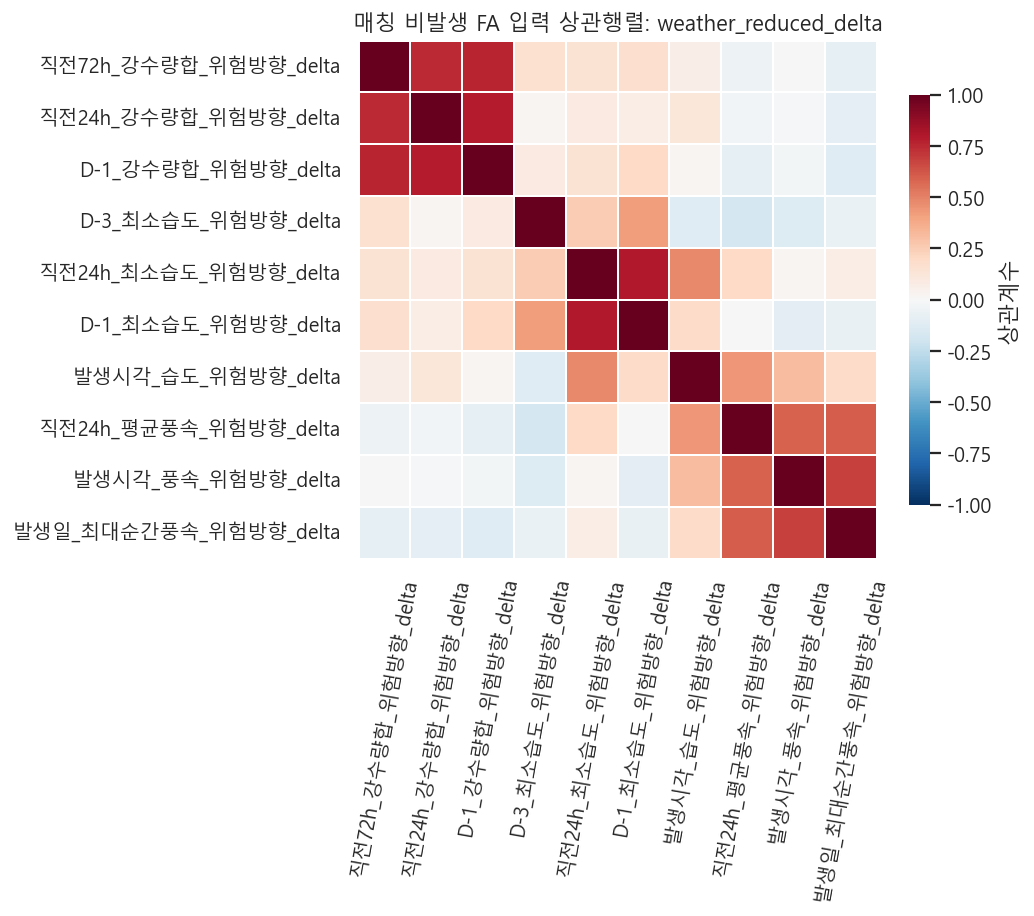

In [11]:
fa_corr = fa_fit_X.corr()

corr_pairs = []
for i, col_i in enumerate(fa_corr.columns):
    for j, col_j in enumerate(fa_corr.columns):
        if j <= i:
            continue
        corr_value = fa_corr.loc[col_i, col_j]
        corr_pairs.append(
            {
                "변수1": col_i,
                "변수2": col_j,
                "상관계수": corr_value,
                "절대상관": abs(corr_value),
            }
        )

fa_high_corr_pairs = (
    pd.DataFrame(corr_pairs)
    .sort_values("절대상관", ascending=False)
    .reset_index(drop=True)
)

if fa_corr.shape[0] >= 3:
    corr_distance = (1 - fa_corr.abs()).fillna(1.0)
    corr_distance_array = corr_distance.to_numpy(copy=True)
    np.fill_diagonal(corr_distance_array, 0.0)
    corr_linkage = linkage(squareform(corr_distance_array, checks=False), method="average")
    corr_order = leaves_list(corr_linkage)
    fa_corr_ordered = fa_corr.iloc[corr_order, corr_order]
else:
    fa_corr_ordered = fa_corr.copy()

display(Markdown("### 절대상관 상위 변수쌍"))
display(fa_high_corr_pairs.head(30).round(4))

fig_width = max(8, 0.55 * fa_corr_ordered.shape[1])
fig_height = max(7, 0.50 * fa_corr_ordered.shape[0])
fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=130)
sns.heatmap(
    fa_corr_ordered,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.75, "label": "상관계수"},
    ax=ax,
)
ax.set_title(f"매칭 비발생 FA 입력 상관행렬: {FA_INPUT_NAME}")
ax.tick_params(axis="x", labelrotation=80)
ax.tick_params(axis="y", labelrotation=0)
plt.tight_layout()
plt.show()


### 7-2. KMO 및 Bartlett 구형성 검정

KMO는 변수들이 공통요인으로 설명될 수 있는지, Bartlett 검정은 상관행렬이 단위행렬이 아닌지 확인한다.


In [13]:
def interpret_kmo(value):
    if pd.isna(value):
        return "계산불가"
    if value >= 0.90:
        return "매우 우수"
    if value >= 0.80:
        return "우수"
    if value >= 0.70:
        return "보통 이상"
    if value >= 0.60:
        return "허용"
    if value >= 0.50:
        return "낮지만 검토 가능"
    return "부적합 검토"


kmo_per_variable, kmo_total = calculate_kmo(fa_fit_X)
kmo_table = (
    pd.DataFrame(
        {
            "변수": fa_fit_X.columns,
            "KMO": kmo_per_variable,
        }
    )
    .assign(판정=lambda df: df["KMO"].map(interpret_kmo))
    .sort_values("KMO")
    .reset_index(drop=True)
)

bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(fa_fit_X)
bartlett_result = pd.DataFrame(
    {
        "검정": ["Bartlett 구형성 검정"],
        "chi_square": [bartlett_chi2],
        "p_value": [bartlett_p],
        "판정": [
            "요인분석 가능" if bartlett_p < 0.05 else "요인분석 부적합 검토"
        ],
    }
)

fa_suitability_summary = pd.DataFrame(
    {
        "항목": [
            "선택 입력셋",
            "표본 수",
            "변수 수",
            "KMO 전체",
            "KMO 판정",
            "KMO 0.50 미만 변수 수",
            "KMO 0.60 미만 변수 수",
            "Bartlett chi-square",
            "Bartlett p-value",
        ],
        "값": [
            FA_INPUT_NAME,
            fa_fit_X.shape[0],
            fa_fit_X.shape[1],
            round(float(kmo_total), 4),
            interpret_kmo(kmo_total),
            int(kmo_table["KMO"].lt(0.50).sum()),
            int(kmo_table["KMO"].lt(0.60).sum()),
            round(float(bartlett_chi2), 4),
            f"{bartlett_p:.6g}",
        ],
    }
)

display(Markdown("### FA 적합성 점검 요약"))
display(fa_suitability_summary)
display(Markdown("### 변수별 KMO"))
display(kmo_table.round(4))
display(Markdown("### Bartlett 구형성 검정"))
display(bartlett_result)

print("생성 객체:")
print("- FA_INPUT_NAME: 현재 선택 입력셋 이름")
print("- fa_fit_X: 상수/결측 제거 후 FA 적합성 점검 입력")
print("- fa_fit_meta: fa_fit_X와 같은 index의 메타데이터")
print("- fa_corr: 상관행렬")
print("- fa_high_corr_pairs: 절대상관 상위 변수쌍")
print("- kmo_table, kmo_total: 변수별/전체 KMO")
print("- bartlett_result: Bartlett 구형성 검정 결과")
print("- fa_suitability_summary: FA 적합성 점검 요약")


### FA 적합성 점검 요약

,항목,값
0,선택 입력셋,weather_reduced_delta
1,표본 수,3395
2,변수 수,10
3,KMO 전체,0.6646
4,KMO 판정,허용
5,KMO 0.50 미만 변수 수,0
6,KMO 0.60 미만 변수 수,3
7,Bartlett chi-square,18103.683
8,Bartlett p-value,0


### 변수별 KMO

,변수,KMO,판정
0,직전24h_최소습도_위험방향_delta,0.5349,낮지만 검토 가능
1,D-1_최소습도_위험방향_delta,0.5393,낮지만 검토 가능
2,발생시각_습도_위험방향_delta,0.5725,낮지만 검토 가능
3,발생일_최대순간풍속_위험방향_delta,0.6513,허용
4,D-3_최소습도_위험방향_delta,0.6736,허용
5,발생시각_풍속_위험방향_delta,0.6942,허용
6,직전24h_강수량합_위험방향_delta,0.7229,보통 이상
7,D-1_강수량합_위험방향_delta,0.7236,보통 이상
8,직전72h_강수량합_위험방향_delta,0.7861,보통 이상
9,직전24h_평균풍속_위험방향_delta,0.7865,보통 이상


### Bartlett 구형성 검정

,검정,chi_square,p_value,판정
0,Bartlett 구형성 검정,18103.682994,0.0,요인분석 가능


생성 객체:
- FA_INPUT_NAME: 현재 선택 입력셋 이름
- fa_fit_X: 상수/결측 제거 후 FA 적합성 점검 입력
- fa_fit_meta: fa_fit_X와 같은 index의 메타데이터
- fa_corr: 상관행렬
- fa_high_corr_pairs: 절대상관 상위 변수쌍
- kmo_table, kmo_total: 변수별/전체 KMO
- bartlett_result: Bartlett 구형성 검정 결과
- fa_suitability_summary: FA 적합성 점검 요약


### 7번 실행 결과 해석: 매칭 비발생 FA 적합성 점검

이번 단계는 `weather_reduced_delta` 입력셋이 매칭 비발생 기반 FA에 들어갈 수 있는지 확인한 것이다.
비발생은 같은 `기상셀ID`, 같은 월, 같은 시간대의 다른 시점이며, 산불 발생시각 전후 `±72h`는 대조군 후보에서 제외했다.

#### 매칭 비발생 대조군 품질
매칭 품질은 매우 안정적이다.
기상셀에 매칭된 산불은 `3,401건`이고, 매칭 비발생 대조군은 총 `17,005행`이다.
산불 1건당 목표 매칭 수는 `5개`였으며, 모든 산불이 목표 매칭 수를 충족했다.
매칭 없음 산불과 목표 미만 산불은 모두 `0건`이고, 산불 발생시점과 대조군의 중복도 `False`로 확인되었다.
기후지형_번지유형별로도 6개 그룹 모두 평균 선택 매칭 수가 `5.0`이므로, 특정 공간 유형에서만 대조군이 부족한 문제는 없다.

| 항목 | 값 |
| --- | ---: |
| 기상셀 매칭 산불 | `3,401` |
| 매칭 비발생 행 수 | `17,005` |
| 목표 매칭 수 | `5` |
| 매칭 산불 수 | `3,401` |
| 매칭 없음 산불 수 | `0` |
| 목표 미만 산불 수 | `0` |
| 산불 1건당 평균 선택 매칭 수 | `5.0` |
| 산불 발생시점과 대조군 중복 여부 | `False` |

#### 위험방향 delta 분포 해석
위험방향 delta는 값이 클수록 같은 장소·월·시간대의 평상시보다 산불 위험 방향으로 이탈했다는 뜻이다.
습도와 강수량은 `매칭 비발생 평균 - 산불값`, 풍속은 `산불값 - 매칭 비발생 평균`으로 계산했다.

습도 delta는 전반적으로 양수 쪽으로 이동했다.
`직전24h_최소습도_위험방향_delta`는 평균 `+8.9759`, 중앙값 `+9.4000`, 양수비율 `79.7118%`이고, `D-1_최소습도_위험방향_delta`도 평균 `+8.6574`, 중앙값 `+9.7320`, 양수비율 `75.9188%`이다.
즉 산불 발생 시점은 같은 장소·계절·시간대의 평상시보다 직전 24시간 및 전일 최소습도가 낮은 경우가 많다.
`발생시각_습도_위험방향_delta`도 평균 `+7.4051`, 중앙값 `+7.9960`, 양수비율 `67.1567%`로 발생 순간의 상대적 저습 경향을 보인다.

강수 delta도 양수 쪽으로 뚜렷하게 이동한다.
`직전72h_강수량합_위험방향_delta`는 평균 `+3.4594`, 중앙값 `+2.0560`, 양수비율 `83.5931%`이고, `직전24h_강수량합_위험방향_delta`는 평균 `+1.2937`, 중앙값 `+0.3400`, 양수비율 `74.0959%`이다.
다만 최솟값이 `-250mm` 안팎까지 내려가는 사례가 있어 강수 delta는 극단 강수 사건의 영향을 받는 비대칭 분포이다.
따라서 FA에서는 강수부족 축으로 해석하되, 이후 요인점수 생성 단계에서 극단값 민감도를 반드시 확인해야 한다.

풍속 delta는 습도·강수보다 약하다.
`발생시각_풍속_위험방향_delta`는 평균 `+0.0989`, 중앙값이 거의 `0`, 양수비율 `49.9265%`로 발생 순간 풍속 자체는 평상시 대비 강한 방향으로 크게 분리되지 않는다.
반면 `발생일_최대순간풍속_위험방향_delta`는 평균 `+0.6753`, 중앙값 `+0.2640`, 양수비율 `53.5137%`이고, `직전24h_평균풍속_위험방향_delta`는 평균 `+0.1770`, 중앙값 `+0.0339`, 양수비율 `51.9847%`이다.
즉 풍속은 모든 산불에서 보편적으로 높아지는 축이라기보다, 일부 강풍 사례를 설명하는 트리거 축으로 보는 것이 적절하다.

#### FA 입력셋 및 결측
FA 기본 입력은 대표 기상 delta 10개 변수인 `weather_reduced_delta`로 설정했다.
원자료는 `3,401행`, 완전케이스는 `3,395행`이며, 상수/단일값 제거 변수와 전부 결측 변수는 없다.
결측은 `D-3_최소습도_위험방향_delta` 6건(`0.18%`), `D-1_최소습도_위험방향_delta` 2건(`0.06%`), `D-1_강수량합_위험방향_delta` 2건(`0.06%`)으로 매우 작다.
따라서 결측 때문에 표본 구조가 왜곡될 가능성은 낮다.

| 입력셋 | 설명 | 변수수 | 완전케이스 |
| --- | --- | ---: | ---: |
| `weather_full_delta` | 전체 기상 위험방향 delta | `19` | `3,395` |
| `weather_reduced_delta` | 대표 기상 위험방향 delta | `10` | `3,395` |
| `mixed_full_delta_topo_access` | 전체 기상 delta + 전체 지형/접근성 | `31` | `2,670` |
| `mixed_reduced_delta_topo_access` | 대표 기상 delta + 대표 지형/접근성 | `18` | `2,670` |

#### 상관행렬 및 플롯 해석
상관행렬 플롯에서는 세 개의 기상 블록이 분명하게 보인다.

첫째, 강수부족 delta 블록이 가장 안정적이다.
`직전24h_강수량합`, `직전72h_강수량합`, `D-1_강수량합` delta가 서로 `0.7477~0.7870` 수준의 높은 양의 상관을 보인다.
이는 최근 24~72시간 및 전일 강수부족이 하나의 공통 축으로 묶일 가능성이 높다는 뜻이다.

둘째, 풍속 delta 블록도 명확하다.
`발생시각_풍속`, `직전24h_평균풍속`, `발생일_최대순간풍속` delta가 `0.5896~0.6815`의 양의 상관을 보인다.
발생 순간 풍속과 당일 최대순간풍속, 직전 24시간 평균풍속이 함께 움직이므로 상대강풍 요인으로 추출될 가능성이 높다.

셋째, 습도 delta 블록은 두 부분으로 나뉜다.
`직전24h_최소습도`와 `D-1_최소습도` delta는 `0.8019`로 매우 강하게 묶인다.
반면 `D-3_최소습도`는 `D-1_최소습도`와 `0.4184`, `직전24h_최소습도`와 `0.2552` 수준이라 장기 선행습도라기보다 별도 잔여 성격을 가질 수 있다.
`발생시각_습도`는 `직전24h_최소습도`와 `0.4774`로 연결되지만, 동시에 `직전24h_평균풍속`과도 `0.4444`, `발생시각_풍속`과 `0.3109`의 양의 상관을 보여 발생 순간의 저습-강풍 복합 조건을 일부 반영한다.

블록 간 상관은 대체로 약하다.
특히 강수부족 블록과 풍속 블록의 상관은 대부분 `|r| < 0.12` 수준이다.
따라서 매칭 비발생 기준의 기상 이탈 구조는 `강수부족`, `상대강풍`, `상대건조`가 비교적 분리된 구조로 나타난다.

| 변수1 | 변수2 | 상관계수 |
| --- | --- | ---: |
| `직전24h_최소습도_delta` | `D-1_최소습도_delta` | `0.8019` |
| `직전24h_강수량합_delta` | `D-1_강수량합_delta` | `0.7870` |
| `직전72h_강수량합_delta` | `D-1_강수량합_delta` | `0.7585` |
| `직전24h_강수량합_delta` | `직전72h_강수량합_delta` | `0.7477` |
| `발생시각_풍속_delta` | `발생일_최대순간풍속_delta` | `0.6815` |
| `직전24h_평균풍속_delta` | `발생일_최대순간풍속_delta` | `0.6040` |
| `발생시각_풍속_delta` | `직전24h_평균풍속_delta` | `0.5896` |

#### KMO 및 Bartlett 결과 해석
전체 KMO는 `0.6646`으로 높지는 않지만 허용 가능한 수준이다.
KMO 0.50 미만 변수는 없고, 0.60 미만 변수는 3개이다.
0.60 미만 변수는 `직전24h_최소습도_delta`(`0.5349`), `D-1_최소습도_delta`(`0.5393`), `발생시각_습도_delta`(`0.5725`)로 모두 습도 관련 변수이다.
이는 습도 delta가 강수·풍속 블록처럼 단일한 공통축으로만 움직이지 않고, 발생시각 저습과 전일/직전24h 저습, D-3 잔여 효과가 섞여 있기 때문으로 해석된다.

Bartlett 구형성 검정은 `chi-square = 18103.6830`, `p-value = 0.0000`으로 유의하다.
상관행렬이 단위행렬이라는 귀무가설은 기각되므로, 변수 간 공통요인 구조는 존재한다.
따라서 `weather_reduced_delta` 입력셋은 요인분석을 진행할 수 있다.
다만 KMO가 0.70 미만이므로 결과를 강하게 일반화하기보다는, 3개 내외의 기상 트리거 축을 확인하는 목적의 FA로 사용하는 것이 적절하다.

| 항목 | 값 |
| --- | ---: |
| 선택 입력셋 | `weather_reduced_delta` |
| 표본 수 | `3,395` |
| 변수 수 | `10` |
| KMO 전체 | `0.6646` |
| KMO 0.50 미만 변수 수 | `0` |
| KMO 0.60 미만 변수 수 | `3` |
| Bartlett chi-square | `18103.6830` |
| Bartlett p-value | `0.0000` |

#### 7번 결론 및 다음 단계
매칭 비발생 기반 대표 기상 delta 10개 변수는 FA 진행이 가능하다.
상관행렬은 `강수부족`, `상대강풍`, `상대건조`의 3개 블록을 강하게 시사한다.
특히 기존 산불 발생 사례 절대값 FA와 달리, 여기서는 공간 입지 요인이 아니라 같은 장소·월·시간대의 평상시 대비 기상 이탈 구조가 중심이다.

다음 단계에서는 `weather_reduced_delta`를 기준으로 Parallel Analysis를 수행해 요인 수를 결정한다.
현재 상관구조만 보면 3요인 해가 가장 자연스럽지만, `D-3_최소습도_delta`가 잔여 요인으로 분리될 수 있으므로 3요인과 4요인 후보를 함께 검토한다.
회전 방식은 기존 FA와 동일하게 `varimax`와 `promax`를 비교하되, 기상 트리거 요인들이 완전히 독립이라고 보기 어렵기 때문에 최종 해석은 `promax`를 우선 검토한다.
